# 주차 공간 탐지 및 인식을 위한 객체 탐지 프로젝트 #2

- **목표: 모델 선택, 모델 훈련, 모델 평가**


In [ ]:
# 구글 드라이브 마운트
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. 모델 선택
- Mask R-CNN
    *  원본 github: https://github.com/matterport/Mask_RCNN
- train/valid/test set으로 8:1:1 분할
- label 형식은 coco json 포맷으로 통합
- 학습 시 다양한 에러가 발생할 수 있으므로, test:val 90장:10장 set을 하나 만들어서 학습 테스트

train에서 90장, val에서 10장 랜덤으로 추출

In [1]:
# 랜덤으로 이미지 추출하여 train, val set 생성
import os
import shutil
import numpy as np

def create_subset(image_dir, label_dir, n, output_dir):
    """
    랜덤으로 n개의 이미지와 라벨 세트를 뽑아 새로운 디렉토리에 저장하는 함수.

    Args:
        image_dir (str): 원본 이미지 디렉토리 경로.
        label_dir (str): 원본 라벨 디렉토리 경로.
        n (int): 뽑을 이미지-라벨 세트의 개수.
        output_dir (str): 출력 디렉토리 경로.

    Returns:
        None
    """
    # 이미지와 라벨 파일 리스트 가져오기
    image_files = sorted(os.listdir(image_dir))
    label_files = sorted(os.listdir(label_dir))

    # 랜덤 인덱스를 이용하여 n개의 세트 뽑기
    if len(image_files) < n:
        raise ValueError("The number of requested samples is greater than the available matched files.")

    indices = np.random.randint(0, len(image_files), n)

    # 출력 디렉토리 생성 (기존 디렉토리 있으면 삭제 후 재생성)
    if os.path.isdir(output_dir):
        shutil.rmtree(output_dir)
    else:
        output_image_dir = os.path.join(output_dir, 'images')
        output_label_dir = os.path.join(output_dir, 'labels')
        os.makedirs(output_image_dir, exist_ok=True)
        os.makedirs(output_label_dir, exist_ok=True)

    # 파일 복사
    for index in indices:
        shutil.copy2(os.path.join(image_dir, image_files[index]), os.path.join(output_image_dir, image_files[index]))
        shutil.copy2(os.path.join(label_dir, label_files[index]), os.path.join(output_label_dir, label_files[index]))


In [2]:
# train 90장 추출
image_dir = 'dataset/train/images'
label_dir = 'dataset/train/labels'

n = 90  # 뽑을 세트 수
output_dir = 'dataset/train_' + str(n)

create_subset(image_dir, label_dir, n, output_dir)

In [3]:
# val 90장 추출
image_dir = 'dataset/val/images'
label_dir = 'dataset/val/labels'

n = 10  # 뽑을 세트 수
output_dir = 'dataset/val_' + str(n)

create_subset(image_dir, label_dir, n, output_dir)

Mask RCNN 모델 학습을 위해 COCO JSON 포맷으로 라벨 통합
- 모델에 맞는 포맷을 쓰지 않으면 에러 발생
- train/validation/test 각각 수행

In [12]:
# 라벨 통합하는 코드
import os
import json
import cv2
import numpy as np

def calculate_area(polygon):
    x = np.array(polygon[::2])
    y = np.array(polygon[1::2])
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

def calculate_bbox(polygon):
    x = polygon[::2]
    y = polygon[1::2]
    return [min(x), min(y), max(x) - min(x), max(y) - min(y)]

def convert_to_coco(input_dir, output_file, directory):
    # 초기 세팅
    coco = {
        "images": [],
        "annotations": [],
        "categories": []
    }

    annotation_id = 0
    category_id_map = {}
    category_id_counter = 1

    # 라벨 변경
    for filename in os.listdir(input_dir):
        if filename.endswith('.json'):
            with open(os.path.join(input_dir, filename), 'r') as f:
                data = json.load(f)

                # 이미지 정보
                img_filename = filename.replace('.json', '.jpg')

                # img = cv2.imread('/content/drive/MyDrive/alice/dataset/' + directory + '/images/' + img_filename)
                # height, width, _ = img.shape

                image_info = {
                    "id": len(coco["images"]),
                    "file_name": img_filename, # 이미지와 라벨의 파일명은 같음
                    "width": 1920,
                    "height": 1080
                }
                coco["images"].append(image_info)

                '''
                # 2D bbox 어노테이션은 필요하면 추가
                for bbox2d in data.get("bbox2d", []):
                    category_name = bbox2d["name"]
                    if category_name not in category_id_map:
                        category_id_map[category_name] = category_id_counter
                        coco["categories"].append({
                            "id": category_id_counter,
                            "name": category_name
                        })
                        category_id_counter += 1

                    bbox = bbox2d["bbox"]
                    x_min, y_min, x_max, y_max = bbox
                    width = x_max - x_min
                    height = y_max - y_min

                    annotation = {
                        "id": annotation_id,
                        "image_id": image_info["id"],
                        "category_id": category_id_map[category_name],
                        "bbox": [x_min, y_min, width, height],
                        "area": width * height,
                        "iscrowd": 0
                    }
                    coco["annotations"].append(annotation)
                    annotation_id += 1
                '''

                # Add segmentations
                for segmentation in data.get("segmentation", []):
                    category_name = segmentation["name"]
                    if category_name not in category_id_map:
                        category_id_map[category_name] = category_id_counter
                        coco["categories"].append({
                            "id": category_id_counter,
                            "name": category_name
                        })
                        category_id_counter += 1

                    # segmentation을 [[x1, y1], [x1, y1], ...] => [x1, y1, x1, y1, ...] 형식으로 수정
                    new_seg = []
                    for x1, y1 in segmentation['polygon']:
                        new_seg.append(x1)
                        new_seg.append(y1)

                    # 면적 및 bbox 계산
                    area = calculate_area(new_seg)
                    bbox = calculate_bbox(new_seg)

                    annotation = {
                        "id": annotation_id,
                        "image_id": image_info["id"],
                        "category_id": category_id_map[category_name],
                        "segmentation": [new_seg],
                        "area": area,
                        "bbox": bbox,
                        "iscrowd": 0
                    }
                    coco["annotations"].append(annotation)
                    annotation_id += 1

    # Save the result to a JSON file
    with open(output_file, 'w') as f: # encoding='utf-8' 조건 추가 가능하지만 오래걸림
        json.dump(coco, f, indent=4) # ensure_ascii=False 조건을 추가하여 한글 깨짐을 해결할 수 있으나 시간 오래 걸림

In [5]:
# .json 파일 생성
for d in ('train_90', 'val_10'):
    print(f'{d} start')
    input_dir = '/content/drive/MyDrive/project/dataset/' + d + '/labels'
    output_file = '/content/drive/MyDrive/project/dataset/' + d + '.json'

    convert_to_coco(input_dir, output_file, d)

train_90 start
val_10 start


## 2. 모델 훈련

모델 학습 전 GPU 가용 상태 확인
- !nvidia-smi 시 GPU가 뜨지 않으면, 런타임 연결을 CPU에서 T4 GPU로 변경 후 코드 재실행

In [6]:
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

2024-08-04 11:06:15.930515: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-04 11:06:16.081054: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-04 11:06:16.131368: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-04 11:06:16.147801: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-04 11:06:16.262939: I tensorflow/core/platform/cpu_feature_guar

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 16411819732771566923
 xla_global_id: -1]

In [7]:
!nvidia-smi

Sun Aug  4 11:06:21 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.27                 Driver Version: 560.70         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 980         On  |   00000000:01:00.0  On |                  N/A |
| 33%   38C    P2             60W /  390W |     772MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

detectron2 설치

In [8]:
!pip install -U torch torchvision
!pip install git+https://github.com/facebookresearch/fvcore.git
import torch, torchvision
torch.__version__

  Cloning https://github.com/facebookresearch/fvcore.git to /tmp/pip-req-build-95xnsl6b
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/fvcore.git /tmp/pip-req-build-95xnsl6b
  Resolved https://github.com/facebookresearch/fvcore.git to commit 1d61132af7413155fedc197f72903d01c624bd01
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.6-py3-none-any.whl size=65574 sha256=f7738d298bdf4a345da389e063051725a31354e3052a29d89c4cf8f1c8033561
  Stored in directory: /tmp/pip-ephem-wheel-cache-4wewf82v/wheels/8f/cb/6a/3b7ac0e01781855ca3d1417ebf9e15e20d5b7fe37ab063aa50
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31532 sha256=72cf43ecf32ec600eb98b7351cf285f1fb728a9504b318671ce8eb9fc210edde
  Stored in directory: /root/.cache/pip/wheels/9a/a3/b6/ac0fcd1b4ed5cfeb3db92e6a0e476cfd48ed0df92b91080c1d
Successfully built fvcore iopath


'2.4.0+cu121'

깃허브 클론 및 필요한 라이브러리 설치

In [9]:
!git clone https://github.com/facebookresearch/detectron2 detectron2_repo

Cloning into 'detectron2_repo'...
remote: Enumerating objects: 15743, done.
remote: Total 15743 (delta 0), reused 0 (delta 0), pack-reused 15743
Receiving objects: 100% (15743/15743), 6.31 MiB | 3.04 MiB/s, done.
Resolving deltas: 100% (11494/11494), done.


In [13]:
# 에러 나면 런타임 재시작 후 다시 이 코드부터 실행
!pip install -e detectron2_repo

Obtaining file:///content/drive/MyDrive/project/detectron2_repo
  Preparing metadata (setup.py) ... done
  Attempting uninstall: detectron2
    Found existing installation: detectron2 0.6
    Uninstalling detectron2-0.6:
      Successfully uninstalled detectron2-0.6
  DEPRECATION: Legacy editable install of detectron2==0.6 from file:///content/drive/MyDrive/project/detectron2_repo (setup.py develop) is deprecated. pip 25.0 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457
  Running setup.py develop for detectron2


In [2]:
# 이 코드 실행 전 커널(런타임) restart 필수
# You may need to restart your runtime prior to this, to let your installation take effect
# Some basic setup
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import matplotlib.pyplot as plt
import numpy as np
import cv2
# from google.colab.patches import cv2_imshow #colab에서만 사용

# import some common detectron2 utilities
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

데이터셋 등록

In [7]:
from detectron2.data.datasets import register_coco_instances
register_coco_instances("train_parking", {}, "/content/drive/MyDrive/project/dataset/train_90.json", "/content/drive/MyDrive/project/dataset/train_90/images")
register_coco_instances("val_parking", {}, "/content/drive/MyDrive/project/dataset/val_10.json", "/content/drive/MyDrive/project/dataset/val_10/images")

In [8]:
val_metadata = MetadataCatalog.get("val_parking")
dataset_dicts = DatasetCatalog.get("val_parking")

[08/04 12:04:19 d2.data.datasets.coco]: Loaded 10 images in COCO format from /content/drive/MyDrive/project/dataset/val_10.json


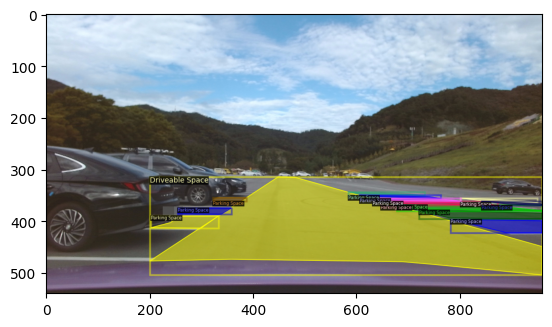

In [9]:
import random
import matplotlib.pyplot as plt

for d in random.sample(dataset_dicts, 3):
    img = cv2.imread(d["file_name"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    visualizer = Visualizer(img[:, :, ::-1], metadata=val_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)    
    plt.imshow(vis.get_image()[:, :, ::-1])

In [10]:
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
import os

cfg = get_cfg()
cfg.TRAIN_NAME = "train_test"
cfg.OUTPUT_DIR = os.path.join('./output', cfg.TRAIN_NAME)
cfg.merge_from_file("./detectron2_repo/configs/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
cfg.DATASETS.TRAIN = ("train_parking",) # 튜플 형태여야 하므로 콤마(,) 필수로 입력해야 함
cfg.DATASETS.TEST = ("val_parking",)   # 튜플 형태여야 하므로 콤마(,) 필수로 입력해야 함
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml") # initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 2

num_gpu = 1
bs = (num_gpu * 2)
cfg.SOLVER.BASE_LR = 0.02 * bs / 16  # pick a good LR

cfg.TEST.EVAL_PERIOD = 100

cfg.SOLVER.MAX_ITER = 1000    # 300 iterations seems good enough, but you can certainly train longer
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128   # faster, and good enough for this toy dataset
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3  # 3 classes

In [ ]:
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

## 3. 모델 평가

test set의 json 파일 생성

In [13]:
d = 'test'
input_dir = 'dataset/' + d + '/labels'
output_file = 'dataset/' + d + '.json'

convert_to_coco(input_dir, output_file, d)

학습한 모델 load 및 threshold 값 설정
- threshold(임계값)는 0~1 사이이며, 값이 높을수록(1에 가까울수록) 명확한 대상만 검출

In [14]:
# Inference should use the config with parameters that are used in training
# cfg now already contains everything we've set previously. We changed it a little bit for inference:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

[08/04 12:04:38 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/train_test/model_final.pth ...


val set을 이용해 샘플 추론

In [15]:
val_metadata = MetadataCatalog.get("val_parking")
dataset_dicts = DatasetCatalog.get("val_parking")

[08/04 12:04:38 d2.data.datasets.coco]: Loaded 10 images in COCO format from /content/drive/MyDrive/project/dataset/val_10.json


/usr/local/lib/python3.10/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


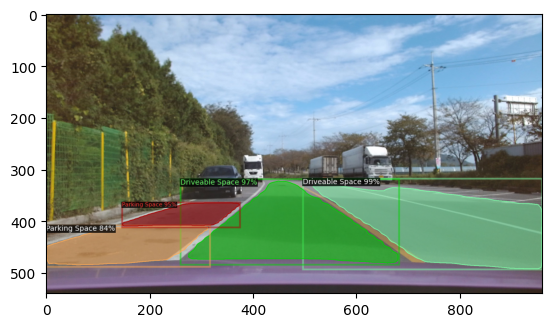

In [16]:
from detectron2.utils.visualizer import ColorMode

for d in random.sample(dataset_dicts, 3):
    img = cv2.imread(d["file_name"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    outputs = predictor(img)  # format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format
    v = Visualizer(img[:, :, ::-1],
                   metadata=val_metadata,
                   scale=0.5  # remove the colors of unsegmented pixels. This option is only available for segmentation models
    )
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    plt.imshow(out.get_image()[:, :, ::-1])

test set을 이용하여 모델 성능 평가
- AP(Average Precision): 객체 검출 시 사용하는 성능 지표
    - AP50: 임계값이 0.5일 때의 AP값
    - AP75: 임계값이 0.75일 때의 AP값
- AP 값이 높을수록 모델의 성능이 좋다는 것을 의미함

In [17]:
from detectron2.data.datasets import register_coco_instances
register_coco_instances("test_parking", {}, "/content/drive/MyDrive/project/dataset/test.json", "/content/drive/MyDrive/project/dataset/test/images")

test_metadata = MetadataCatalog.get("test_parking")
dataset_dicts = DatasetCatalog.get("test_parking")

[08/04 12:04:45 d2.data.datasets.coco]: Loaded 788 images in COCO format from /content/drive/MyDrive/project/dataset/test.json


In [18]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
import os

evaluator = COCOEvaluator("test_parking", output_dir=os.path.join("./output/inference", cfg.TRAIN_NAME))
test_loader = build_detection_test_loader(cfg, "test_parking")
print(inference_on_dataset(predictor.model, test_loader, evaluator))

[08/04 12:04:55 d2.data.datasets.coco]: Loaded 788 images in COCO format from /content/drive/MyDrive/project/dataset/test.json
[08/04 12:04:55 d2.data.build]: Distribution of instances among all 2 categories:
|   category    | #instances   |   category    | #instances   |
|:-------------:|:-------------|:-------------:|:-------------|
| Driveable S.. | 991          | Parking Space | 3752         |
|               |              |               |              |
|     total     | 4743         |               |              |
[08/04 12:04:55 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[08/04 12:04:55 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[08/04 12:04:55 d2.data.common]: Serializing 788 elements to byte tensors and concatenating them all ...
[08/04 12:04:55 d2.data.common]: Serialized dataset takes 1.12 MiB
[0